# PHÂN TÍCH KHÁM PHÁ DỮ LIỆU (EDA)  
## Bộ dữ liệu chẩn đoán bệnh tim (`heart.csv`)

Notebook này thực hiện phân tích khám phá dữ liệu cho bộ dữ liệu bệnh tim nhằm phục vụ các bước:
- hiểu đặc điểm dữ liệu ban đầu
- kiểm tra chất lượng dữ liệu
- hỗ trợ tiền xử lý
- hỗ trợ xây dựng mô hình chẩn đoán bệnh

**Biến mục tiêu gốc:** `condition`  
> Ghi chú: trong bước preprocessing, nhóm có thể đổi tên `condition` thành `diagnosis` để đồng bộ với phần mô hình.

## 1. Import thư viện

In [1]:
from pathlib import Path
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình hiển thị
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1200)
pd.set_option("display.max_colwidth", None)

# Cấu hình biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

# Tắt một số warning không cần thiết
warnings.filterwarnings("ignore", category=FutureWarning)

## 2. Xác định đường dẫn dữ liệu

Notebook sẽ thử tìm file `heart.csv` theo nhiều vị trí khác nhau để tránh lỗi đường dẫn khi mở bằng Jupyter hoặc PyCharm.

In [2]:
def find_dataset():
    candidate_paths = [
        Path("heart.csv"),
        Path("../../data/raw/heart.csv"),
        Path("../data/raw/heart.csv"),
        Path("data/raw/heart.csv"),
        Path("/mnt/data/heart.csv"),  # dùng được khi chạy trong môi trường xuất file
    ]

    for path in candidate_paths:
        if path.exists():
            return path.resolve()

    raise FileNotFoundError(
        "Không tìm thấy file heart.csv. "
        "Hãy đặt file vào data/raw/heart.csv hoặc mở notebook đúng trong project."
    )

DATA_PATH = find_dataset()
DATA_PATH

WindowsPath('D:/data_mining/data/raw/heart.csv')

## 3. Đọc dữ liệu

In [3]:
df = pd.read_csv(DATA_PATH)

print("Đọc dữ liệu thành công!")
print(f"Đường dẫn: {DATA_PATH}")
print(f"Kích thước dữ liệu: {df.shape[0]} dòng x {df.shape[1]} cột")

Đọc dữ liệu thành công!
Đường dẫn: D:\data_mining\data\raw\heart.csv
Kích thước dữ liệu: 297 dòng x 14 cột


## 4. Xem nhanh dữ liệu

In [4]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


In [5]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
292,40,1,3,152,223,0,0,181,0,0.0,0,0,2,1
293,39,1,3,118,219,0,0,140,0,1.2,1,0,2,1
294,35,1,3,120,198,0,0,130,1,1.6,1,0,2,1
295,35,0,3,138,183,0,0,182,0,1.4,0,0,0,0
296,35,1,3,126,282,0,2,156,1,0.0,0,0,2,1


In [6]:
print("Danh sách cột:")
df.columns.tolist()

Danh sách cột:


['age',
 'sex',
 'cp',
 'trestbps',
 'chol',
 'fbs',
 'restecg',
 'thalach',
 'exang',
 'oldpeak',
 'slope',
 'ca',
 'thal',
 'condition']

## 5. Thông tin tổng quát dữ liệu

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        297 non-null    int64  
 1   sex        297 non-null    int64  
 2   cp         297 non-null    int64  
 3   trestbps   297 non-null    int64  
 4   chol       297 non-null    int64  
 5   fbs        297 non-null    int64  
 6   restecg    297 non-null    int64  
 7   thalach    297 non-null    int64  
 8   exang      297 non-null    int64  
 9   oldpeak    297 non-null    float64
 10  slope      297 non-null    int64  
 11  ca         297 non-null    int64  
 12  thal       297 non-null    int64  
 13  condition  297 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 32.6 KB


In [8]:
df.dtypes

age            int64
sex            int64
cp             int64
trestbps       int64
chol           int64
fbs            int64
restecg        int64
thalach        int64
exang          int64
oldpeak      float64
slope          int64
ca             int64
thal           int64
condition      int64
dtype: object

## 6. Kiểm tra chất lượng dữ liệu
### 6.1. Kiểm tra dữ liệu thiếu

In [9]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope        0
ca           0
thal         0
condition    0
dtype: int64

In [10]:
total_missing = int(df.isnull().sum().sum())
print("Tổng số giá trị thiếu:", total_missing)

if total_missing == 0:
    print("=> Bộ dữ liệu không có missing values.")
else:
    print("=> Bộ dữ liệu có missing values, cần xử lý trước khi mô hình hóa.")

Tổng số giá trị thiếu: 0
=> Bộ dữ liệu không có missing values.


### 6.2. Kiểm tra dữ liệu trùng

In [11]:
duplicate_count = int(df.duplicated().sum())
print("Số dòng bị trùng:", duplicate_count)

if duplicate_count == 0:
    print("=> Không có dữ liệu trùng.")
else:
    print("=> Có dữ liệu trùng, cần loại bỏ trước khi tiền xử lý.")

Số dòng bị trùng: 0
=> Không có dữ liệu trùng.


## 7. Thống kê mô tả dữ liệu

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,297.0,54.542088,9.049736,29.0,48.0,56.0,61.0,77.0
sex,297.0,0.676768,0.468500,0.0,0.0,1.0,1.0,1.0
cp,297.0,2.158249,0.964859,0.0,2.0,2.0,3.0,3.0
trestbps,297.0,131.693603,17.762806,94.0,120.0,130.0,140.0,200.0
chol,297.0,247.350168,51.997583,126.0,211.0,243.0,276.0,564.0
fbs,297.0,0.144781,0.352474,0.0,0.0,0.0,0.0,1.0
restecg,297.0,0.996633,0.994914,0.0,0.0,1.0,2.0,2.0
thalach,297.0,149.599327,22.941562,71.0,133.0,153.0,166.0,202.0
exang,297.0,0.326599,0.469761,0.0,0.0,0.0,1.0,1.0
oldpeak,297.0,1.055556,1.166123,0.0,0.0,0.8,1.6,6.2


## 8. Mô tả ý nghĩa các thuộc tính

In [13]:
feature_description = pd.DataFrame({
    "feature": [
        "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
        "thalach", "exang", "oldpeak", "slope", "ca", "thal", "condition"
    ],
    "description": [
        "Tuổi",
        "Giới tính (1: nam, 0: nữ)",
        "Loại đau ngực",
        "Huyết áp lúc nghỉ",
        "Cholesterol huyết thanh",
        "Đường huyết lúc đói > 120 mg/dl",
        "Kết quả điện tâm đồ lúc nghỉ",
        "Nhịp tim tối đa đạt được",
        "Đau thắt ngực do gắng sức",
        "Mức ST chênh xuống do gắng sức",
        "Độ dốc đoạn ST",
        "Số lượng mạch máu lớn được nhuộm màu",
        "Kết quả thalassemia",
        "Biến mục tiêu: có bệnh tim hay không"
    ]
})
feature_description

,feature,description
0,age,Tuổi
1,sex,"Giới tính (1: nam, 0: nữ)"
2,cp,Loại đau ngực
3,trestbps,Huyết áp lúc nghỉ
4,chol,Cholesterol huyết thanh
5,fbs,Đường huyết lúc đói > 120 mg/dl
6,restecg,Kết quả điện tâm đồ lúc nghỉ
7,thalach,Nhịp tim tối đa đạt được
8,exang,Đau thắt ngực do gắng sức
9,oldpeak,Mức ST chênh xuống do gắng sức


## 9. Phân tích biến mục tiêu `condition`

Biến `condition` là nhãn của bài toán phân lớp.  
Cần kiểm tra số lượng và tỷ lệ các lớp để xem dữ liệu có bị mất cân bằng hay không.

In [14]:
condition_counts = df["condition"].value_counts().sort_index()
condition_percent = (df["condition"].value_counts(normalize=True).sort_index() * 100).round(2)

print("Số lượng theo từng lớp:")
print(condition_counts)

print("\nTỷ lệ phần trăm theo từng lớp:")
print(condition_percent)

Số lượng theo từng lớp:
condition
0    160
1    137
Name: count, dtype: int64

Tỷ lệ phần trăm theo từng lớp:
condition
0    53.87
1    46.13
Name: proportion, dtype: float64


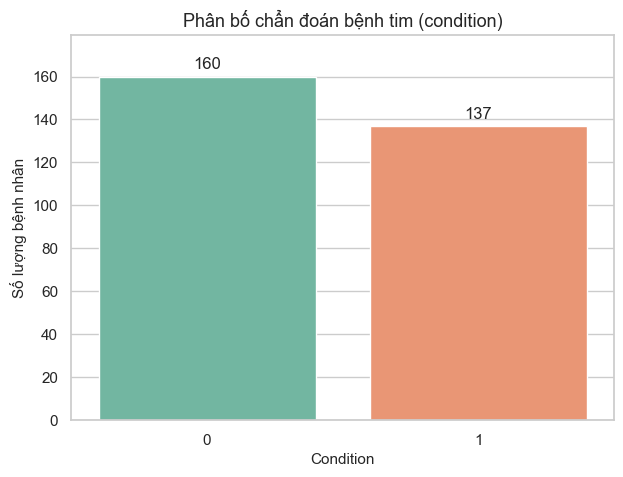

In [15]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(
    x="condition",
    hue="condition",
    data=df,
    palette="Set2",
    legend=False,
    dodge=False
)

for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

ax.set_title("Phân bố chẩn đoán bệnh tim (condition)")
ax.set_xlabel("Condition")
ax.set_ylabel("Số lượng bệnh nhân")
ax.margins(y=0.12)
plt.show()

## 10. Phân tích các thuộc tính số

In [16]:
numeric_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]
numeric_cols

['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

In [17]:
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,297.0,54.542088,9.049736,29.0,48.0,56.0,61.0,77.0
trestbps,297.0,131.693603,17.762806,94.0,120.0,130.0,140.0,200.0
chol,297.0,247.350168,51.997583,126.0,211.0,243.0,276.0,564.0
thalach,297.0,149.599327,22.941562,71.0,133.0,153.0,166.0,202.0
oldpeak,297.0,1.055556,1.166123,0.0,0.0,0.8,1.6,6.2


### 10.1. Histogram các thuộc tính số

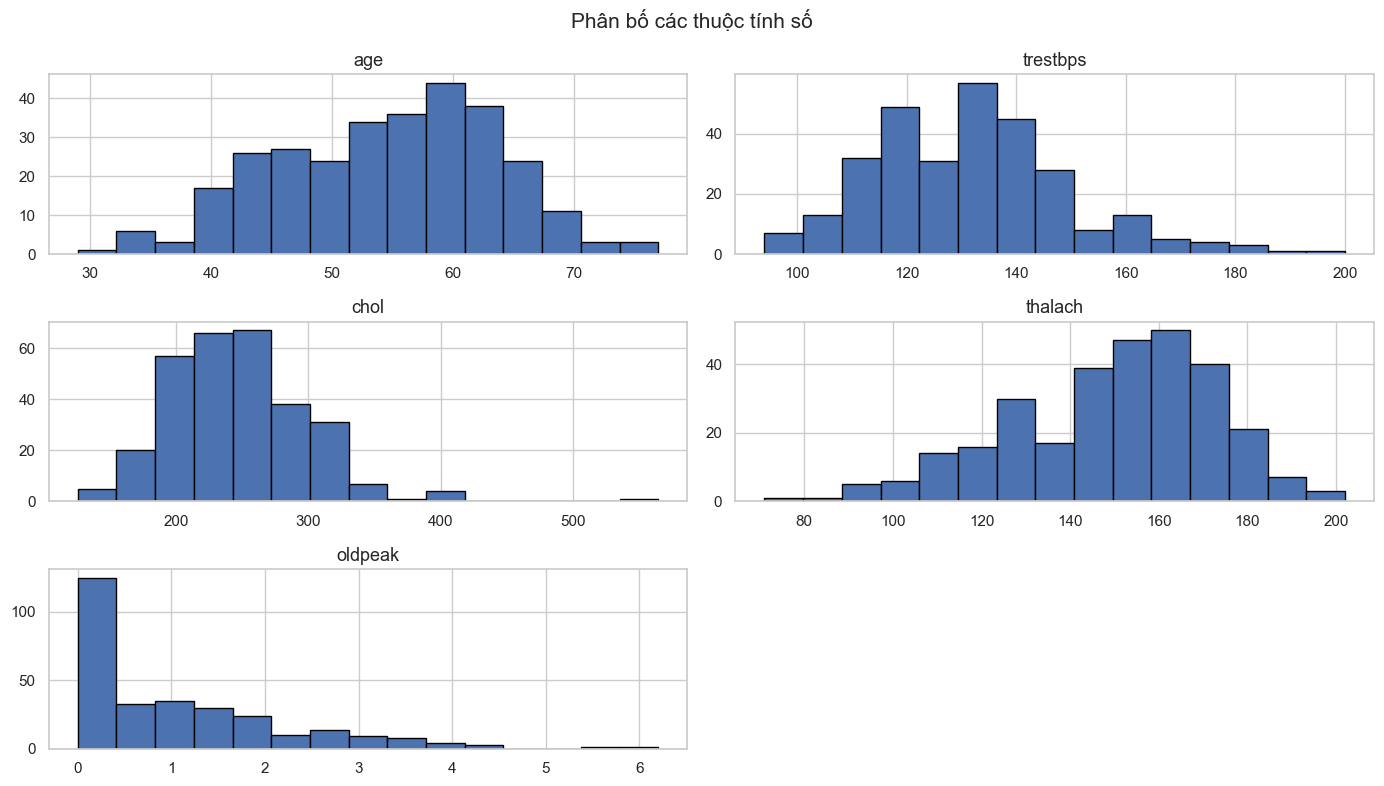

In [18]:
df[numeric_cols].hist(bins=15, figsize=(14, 8), edgecolor="black")
plt.suptitle("Phân bố các thuộc tính số", fontsize=15)
plt.tight_layout()
plt.show()

### 10.2. Boxplot phát hiện outlier

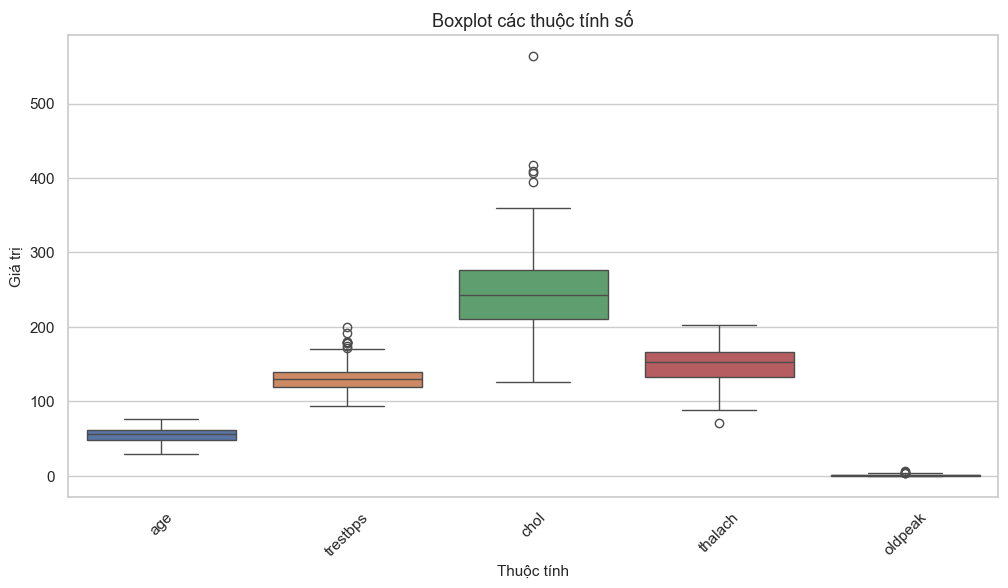

In [19]:
plt.figure(figsize=(12, 6))
ax = sns.boxplot(data=df[numeric_cols])
ax.set_title("Boxplot các thuộc tính số")
ax.set_xlabel("Thuộc tính")
ax.set_ylabel("Giá trị")
plt.xticks(rotation=45)
plt.show()

### 10.3. So sánh từng thuộc tính số theo `condition`

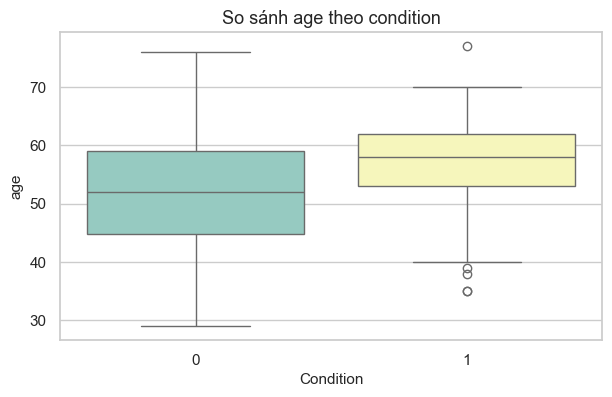

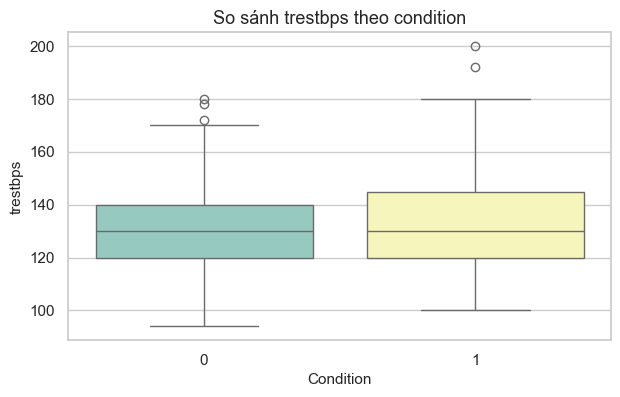

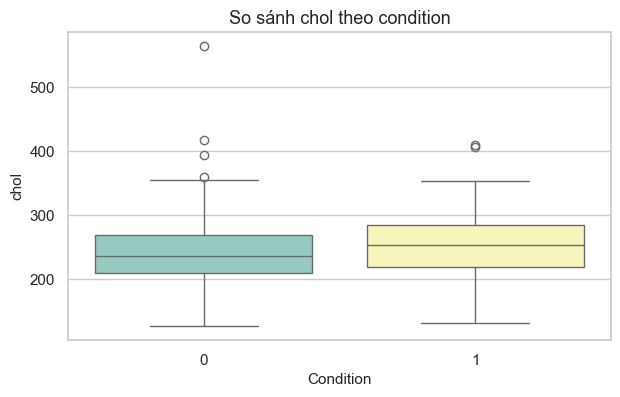

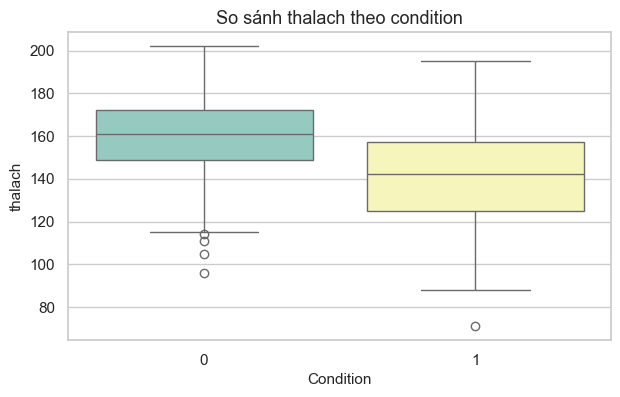

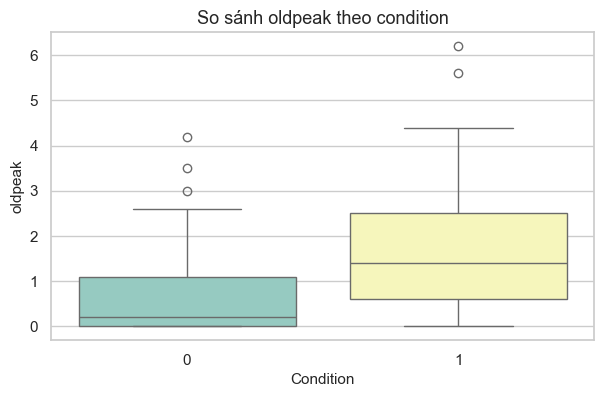

In [20]:
for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    ax = sns.boxplot(
        x="condition",
        y=col,
        hue="condition",
        data=df,
        palette="Set3",
        legend=False
    )
    ax.set_title(f"So sánh {col} theo condition")
    ax.set_xlabel("Condition")
    ax.set_ylabel(col)
    plt.show()

## 11. Phân tích các thuộc tính phân loại / đã mã hóa

In [21]:
categorical_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]
categorical_cols

['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

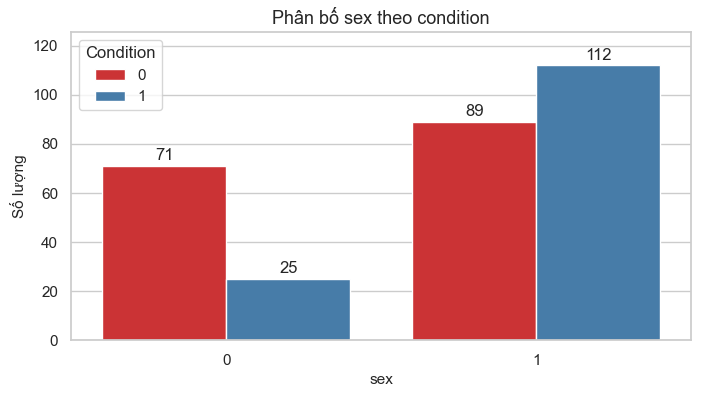

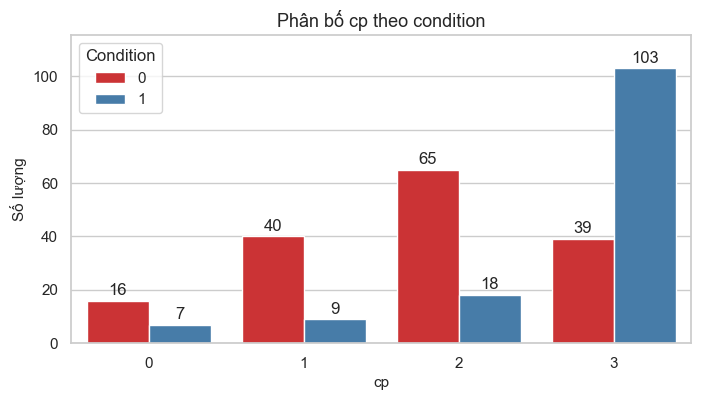

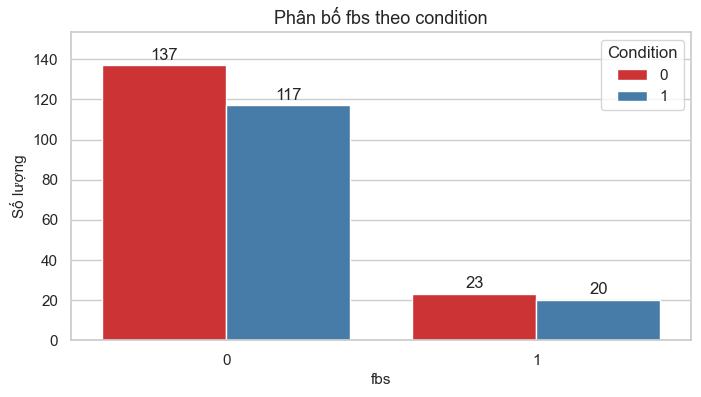

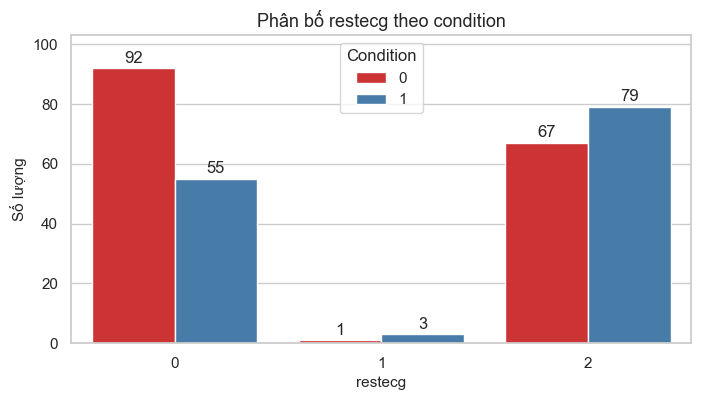

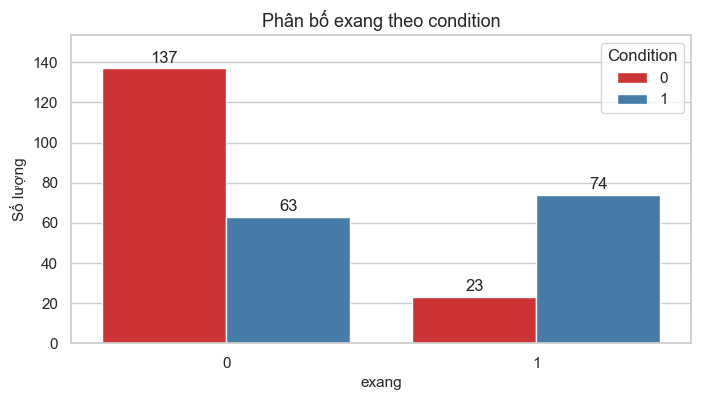

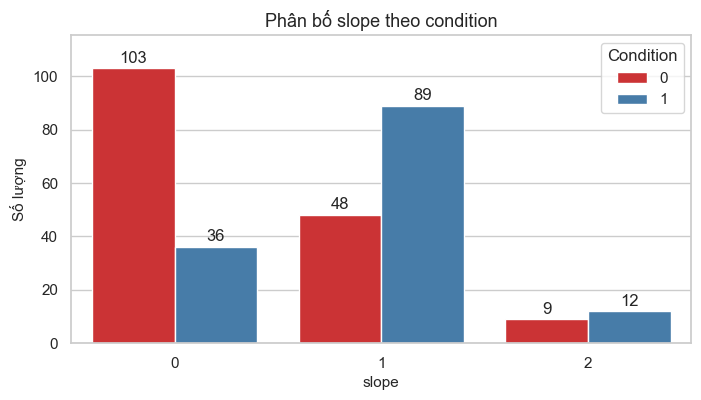

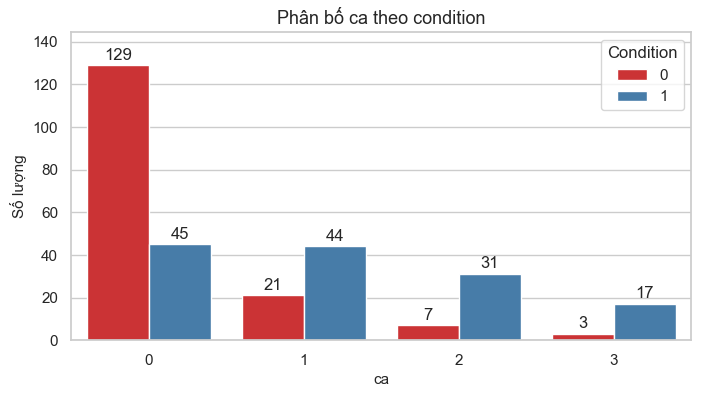

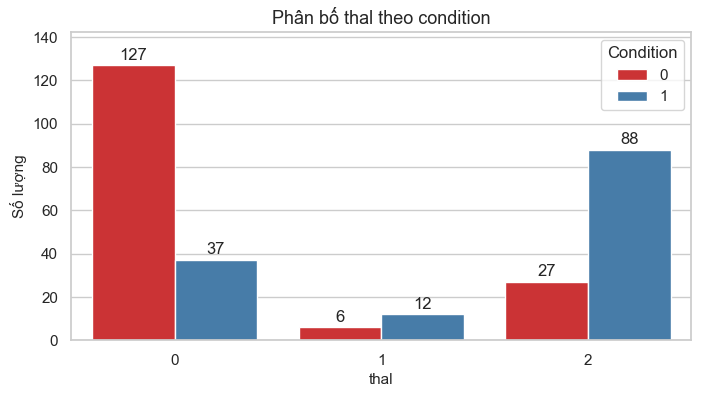

In [22]:
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    ax = sns.countplot(
        x=col,
        hue="condition",
        data=df,
        palette="Set1"
    )

    for container in ax.containers:
        ax.bar_label(container, fmt="%d", padding=2)

    ax.set_title(f"Phân bố {col} theo condition")
    ax.set_xlabel(col)
    ax.set_ylabel("Số lượng")
    ax.legend(title="Condition")
    ax.margins(y=0.12)
    plt.show()

## 12. Phân tích tương quan

In [23]:
corr_matrix = df.corr(numeric_only=True)
corr_matrix

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
age,1.000000,-0.092399,0.110471,0.290476,0.202644,0.132062,0.149917,-0.394563,0.096489,0.197123,0.159405,0.362210,0.120795,0.227075
sex,-0.092399,1.000000,0.008908,-0.066340,-0.198089,0.038850,0.033897,-0.060496,0.143581,0.106567,0.033345,0.091925,0.370556,0.278467
cp,0.110471,0.008908,1.000000,-0.036980,0.072088,-0.057663,0.063905,-0.339308,0.377525,0.203244,0.151079,0.235644,0.266275,0.408945
trestbps,0.290476,-0.066340,-0.036980,1.000000,0.131536,0.180860,0.149242,-0.049108,0.066691,0.191243,0.121172,0.097954,0.130612,0.153490
chol,0.202644,-0.198089,0.072088,0.131536,1.000000,0.012708,0.165046,-0.000075,0.059339,0.038596,-0.009215,0.115945,0.023441,0.080285
fbs,0.132062,0.038850,-0.057663,0.180860,0.012708,1.000000,0.068831,-0.007842,-0.000893,0.008311,0.047819,0.152086,0.051038,0.003167
restecg,0.149917,0.033897,0.063905,0.149242,0.165046,0.068831,1.000000,-0.072290,0.081874,0.113726,0.135141,0.129021,0.013612,0.166343
thalach,-0.394563,-0.060496,-0.339308,-0.049108,-0.000075,-0.007842,-0.072290,1.000000,-0.384368,-0.347640,-0.389307,-0.268727,-0.258386,-0.423817
exang,0.096489,0.143581,0.377525,0.066691,0.059339,-0.000893,0.081874,-0.384368,1.000000,0.289310,0.250572,0.148232,0.323268,0.421355
oldpeak,0.197123,0.106567,0.203244,0.191243,0.038596,0.008311,0.113726,-0.347640,0.289310,1.000000,0.579037,0.294452,0.336809,0.424052


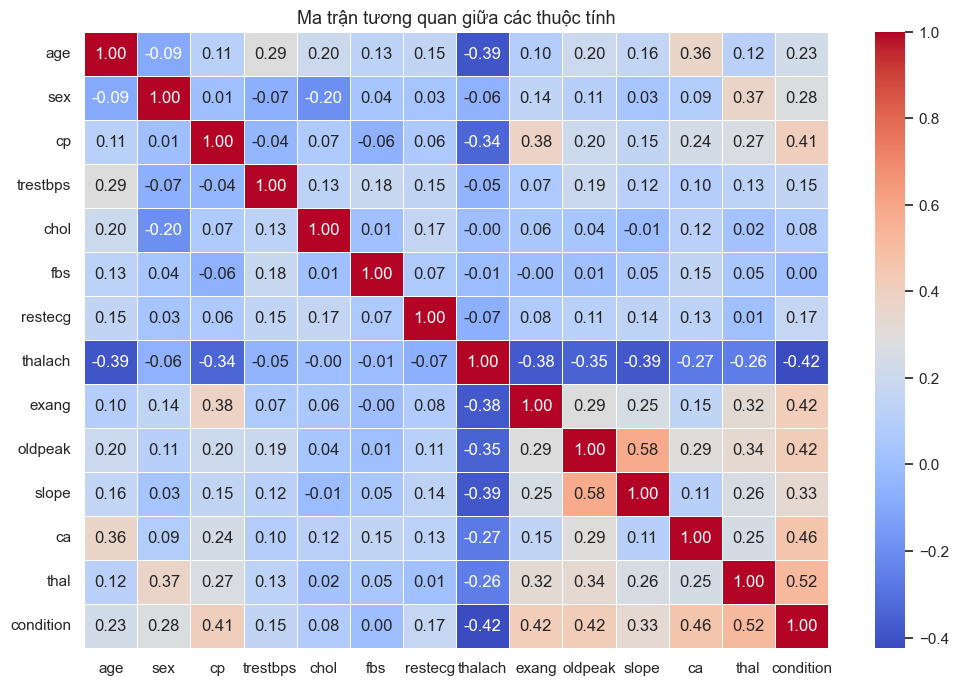

In [24]:
plt.figure(figsize=(12, 8))
ax = sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)
ax.set_title("Ma trận tương quan giữa các thuộc tính")
plt.show()

In [25]:
target_corr = corr_matrix["condition"].sort_values(ascending=False)
target_corr

condition    1.000000
thal         0.520516
ca           0.463189
oldpeak      0.424052
exang        0.421355
cp           0.408945
slope        0.333049
sex          0.278467
age          0.227075
restecg      0.166343
trestbps     0.153490
chol         0.080285
fbs          0.003167
thalach     -0.423817
Name: condition, dtype: float64

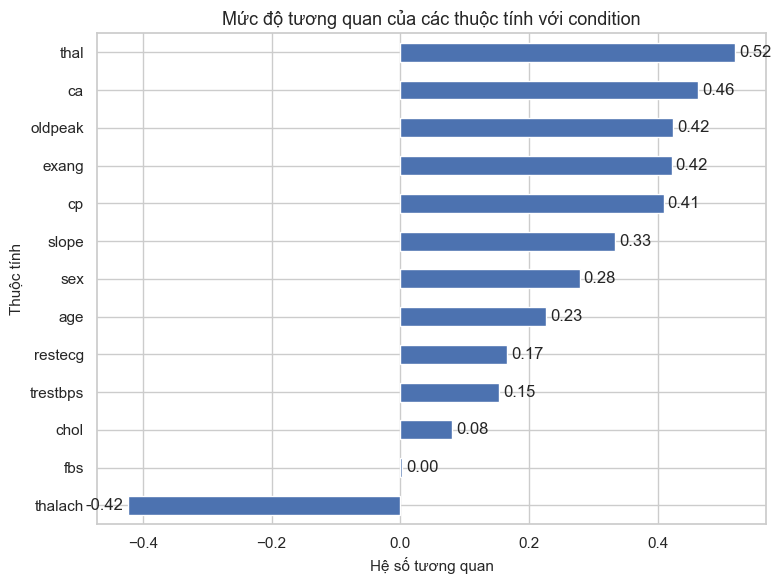

In [26]:
plt.figure(figsize=(8, 6))
ax = target_corr.drop("condition").sort_values().plot(kind="barh")
ax.set_title("Mức độ tương quan của các thuộc tính với condition")
ax.set_xlabel("Hệ số tương quan")
ax.set_ylabel("Thuộc tính")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.tight_layout()
plt.show()

## 13. Một số phân tích nhóm đơn giản theo nhãn bệnh

In [27]:
group_summary = df.groupby("condition")[numeric_cols].mean().round(2)
group_summary

,age,trestbps,chol,thalach,oldpeak
condition,,,,,
0,52.64,129.18,243.49,158.58,0.60
1,56.76,134.64,251.85,139.11,1.59


<Figure size 1000x600 with 0 Axes>

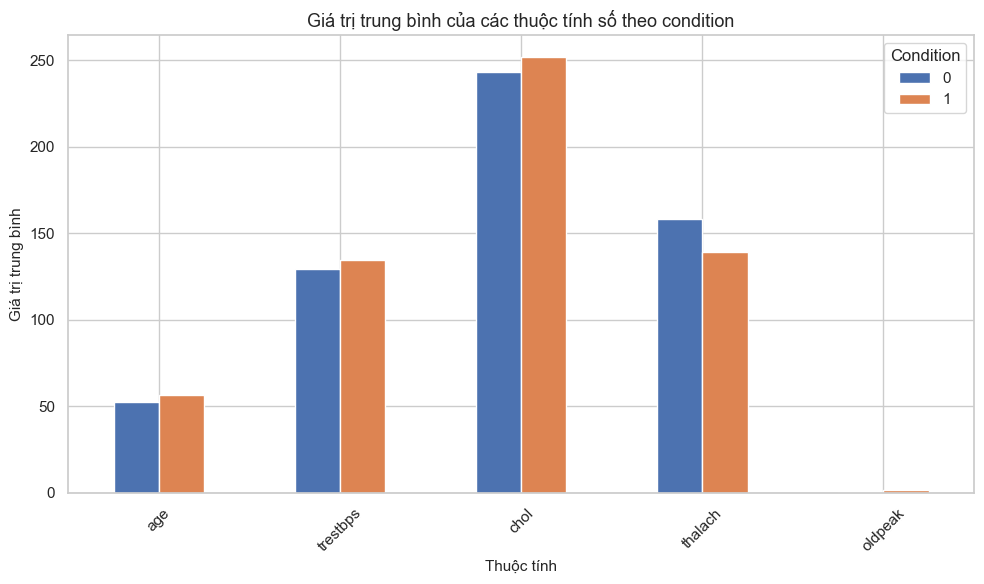

In [28]:
plt.figure(figsize=(10, 6))
group_summary.T.plot(kind="bar")
plt.title("Giá trị trung bình của các thuộc tính số theo condition")
plt.xlabel("Thuộc tính")
plt.ylabel("Giá trị trung bình")
plt.xticks(rotation=45)
plt.legend(title="Condition")
plt.tight_layout()
plt.show()

## 14. Kết luận EDA

In [29]:
print("KẾT LUẬN PHÂN TÍCH KHÁM PHÁ DỮ LIỆU")
print("- Bộ dữ liệu gồm", df.shape[0], "dòng và", df.shape[1], "cột.")
print("- Dữ liệu không có missing values và không có dòng trùng.")
print("- Biến mục tiêu là 'condition', phù hợp cho bài toán phân lớp bệnh tim.")
print("- Một số thuộc tính số quan trọng gồm: age, trestbps, chol, thalach, oldpeak.")
print("- Ma trận tương quan giúp xác định các thuộc tính ảnh hưởng đến biến mục tiêu.")
print("- Kết quả EDA là cơ sở cho bước tiền xử lý, chọn đặc trưng và xây dựng mô hình chẩn đoán bệnh.")

KẾT LUẬN PHÂN TÍCH KHÁM PHÁ DỮ LIỆU
- Bộ dữ liệu gồm 297 dòng và 14 cột.
- Dữ liệu không có missing values và không có dòng trùng.
- Biến mục tiêu là 'condition', phù hợp cho bài toán phân lớp bệnh tim.
- Một số thuộc tính số quan trọng gồm: age, trestbps, chol, thalach, oldpeak.
- Ma trận tương quan giúp xác định các thuộc tính ảnh hưởng đến biến mục tiêu.
- Kết quả EDA là cơ sở cho bước tiền xử lý, chọn đặc trưng và xây dựng mô hình chẩn đoán bệnh.
